# AI-Generated Text Detection: Complete Model and Evaluation Analysis

**Datasets.** DAIGT V2 (student essays, human vs machine) and HC3 (question-answer pairs, human vs ChatGPT). Full corpora, no sampling.

**What this notebook covers**

1. Data loading and integrity checks
2. Exploratory analysis, including the class-balance check that decides whether SMOTE is required
3. Text representations: bag-of-words, TF-IDF, character n-grams
4. A sweep over 12 classical model families, multiple solvers and both representations
5. Every requested metric: accuracy, precision, recall, F1 (macro, weighted, per class), ROC-AUC, PR-AUC
6. Confusion matrices, ROC curves, precision-recall curves for every model
7. Feature importance and SHAP explanations
8. Overfitting diagnostics: learning curves, train-versus-test gaps, cross-validation
9. Fine-tuned transformer results (BERT, DeBERTa) for comparison
10. A single master comparison table and the selected best model

Every split is the project's fixed partition, so results here are directly comparable with the paper.

## 1. Setup and configuration

In [1]:
import json, re, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

PROJECT = Path.cwd()
WORK    = PROJECT / 'paper_scale' / 'work'
MODELS  = PROJECT / 'paper_scale' / 'models'
FIGDIR  = PROJECT / 'notebook_figures'
FIGDIR.mkdir(exist_ok=True)

DATASETS = {'D1': 'DAIGT V2', 'D2': 'HC3'}
LABELS   = {0: 'human', 1: 'machine'}

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
                     'axes.grid': True, 'grid.alpha': 0.3})
# colourblind-safe palette used consistently throughout
PALETTE = ['#0072B2', '#E69F00', '#009E73', '#D55E00', '#CC79A7', '#56B4E9', '#F0E442', '#000000']
sns.set_palette(PALETTE)

print('seed        :', SEED)
print('project root:', PROJECT)
print('figures ->  :', FIGDIR)

seed        : 42
project root: /media/filwel/All/Sakib/Semester 10/ NATURAL LANGUAGE PROCESSING /Final
figures ->  : /media/filwel/All/Sakib/Semester 10/ NATURAL LANGUAGE PROCESSING /Final/notebook_figures


## 2. Data loading and integrity checks

Both corpora are class-balanced and pre-partitioned. The partition is fixed and duplicate-group aware, meaning near-identical documents are kept on the same side of the split so no near-duplicate can leak from training into test.

Training uses 80% of each corpus (72% fit + 8% validation) and the held-out test set is 20%.

In [2]:
data, splits = {}, {}
rows = []
for tag, name in DATASETS.items():
    df = pd.read_parquet(WORK / f'data_{tag}.parquet')
    sp = np.load(WORK / f'split_{tag}.npz')
    data[tag], splits[tag] = df, {k: sp[k] for k in ('train', 'val', 'test')}
    n = len(df)
    rows.append({
        'dataset': name, 'documents': n,
        'train': len(sp['train']), 'val': len(sp['val']), 'test': len(sp['test']),
        'train %': f"{len(sp['train'])/n:.1%}", 'val %': f"{len(sp['val'])/n:.1%}",
        'test %': f"{len(sp['test'])/n:.1%}",
        'human': int((df.label == 0).sum()), 'machine': int((df.label == 1).sum()),
    })

overview = pd.DataFrame(rows).set_index('dataset')
display(overview)

# integrity: no index may appear in more than one partition
for tag, name in DATASETS.items():
    s = splits[tag]
    a, b, c = set(s['train']), set(s['val']), set(s['test'])
    assert not (a & b) and not (a & c) and not (b & c), f'{name}: partitions overlap'
    assert len(a | b | c) == len(data[tag]), f'{name}: partition does not cover the corpus'
print('integrity checks passed: partitions are disjoint and cover every document')

,documents,train,val,test,train %,val %,test %,human,machine
dataset,,,,,,,,,
DAIGT V2,34994,25196,2800,6998,72.0%,8.0%,20.0%,17497,17497
HC3,53806,38785,4289,10732,72.1%,8.0%,19.9%,26903,26903


integrity checks passed: partitions are disjoint and cover every document


## 3. Exploratory data analysis

### 3.1 Class balance, and whether SMOTE is required

SMOTE (or any resampling) is only appropriate when classes are imbalanced. The check below decides that question from the data rather than assuming it.

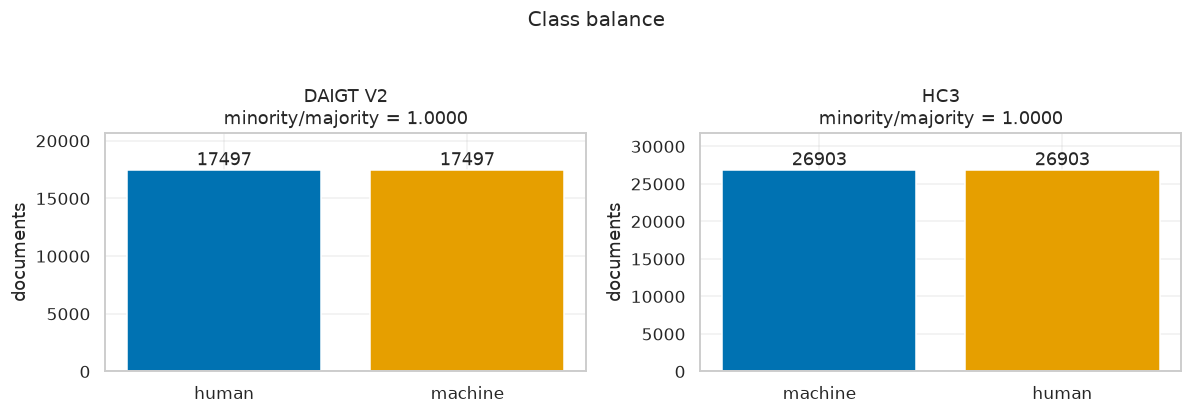

SMOTE / resampling decision
  DAIGT V2  imbalanced? False  ->  NOT required, classes are balanced
  HC3       imbalanced? False  ->  NOT required, classes are balanced


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
smote_needed = {}
for ax, (tag, name) in zip(axes, DATASETS.items()):
    df = data[tag]
    counts = df.label.map(LABELS).value_counts()
    ratio = counts.min() / counts.max()
    smote_needed[name] = ratio < 0.8          # common rule of thumb
    bars = ax.bar(counts.index, counts.values, color=[PALETTE[0], PALETTE[1]])
    ax.bar_label(bars, fmt='%d')
    ax.set_title(f'{name}\nminority/majority = {ratio:.4f}')
    ax.set_ylabel('documents')
    ax.set_ylim(0, counts.max() * 1.18)
plt.suptitle('Class balance', y=1.04, fontsize=13)
plt.tight_layout(); plt.savefig(FIGDIR / 'class_balance.png'); plt.show()

print('SMOTE / resampling decision')
for name, need in smote_needed.items():
    print(f'  {name:9s} imbalanced? {need}  ->  '
          f"{'APPLY resampling' if need else 'NOT required, classes are balanced'}")

Both corpora are balanced to four decimal places, so **no resampling is applied anywhere in this notebook**. Applying SMOTE to balanced data would synthesise examples that add noise without correcting any skew, and would make the reported metrics less comparable with the paper.

### 3.2 Document length distributions

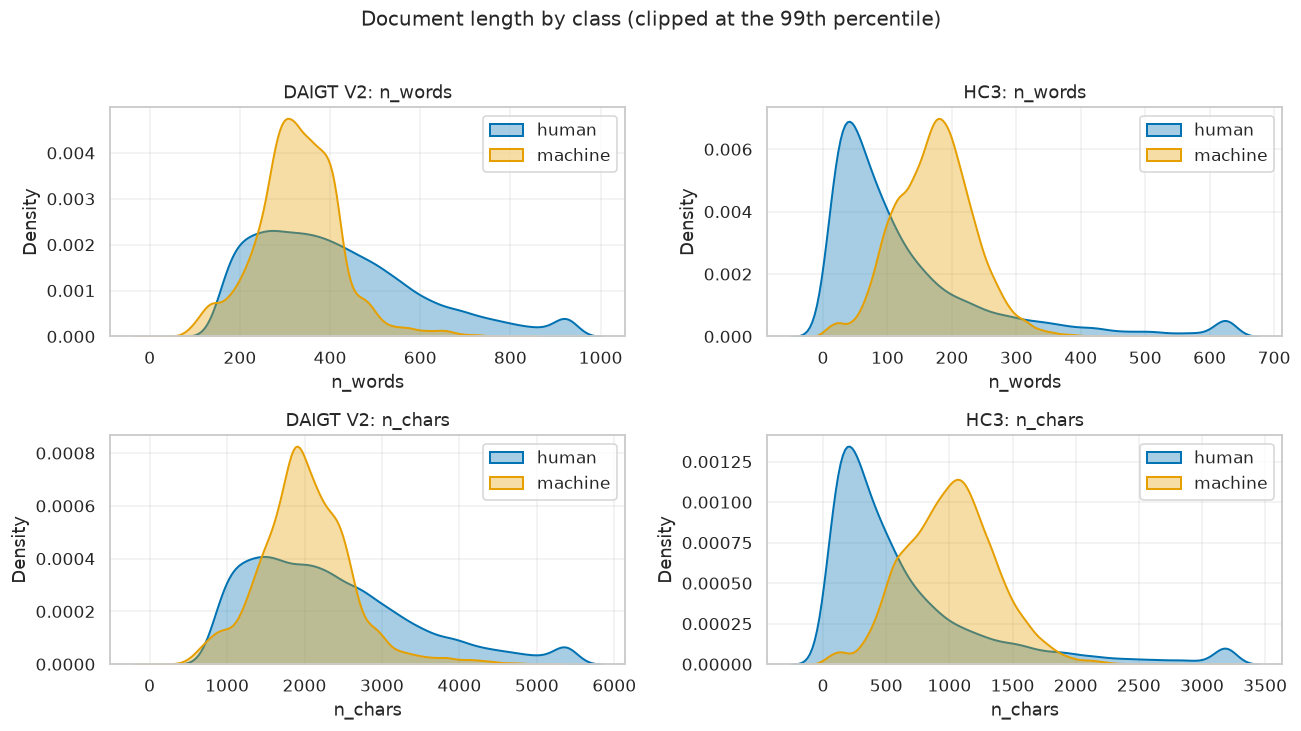

median words  mean words  median chars  mean chars
dataset  class                                                      
DAIGT V2 human           382.0       416.4        2125.0      2337.4
         machine         328.0       329.4        1973.0      2009.3
HC3      human            83.0       134.7         423.0       684.7
         machine         174.0       173.1        1012.0      1010.5

In [4]:
for tag in DATASETS:
    df = data[tag]
    df['n_chars'] = df.text.str.len()
    df['n_words'] = df.text.str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(12, 6.5))
for j, (tag, name) in enumerate(DATASETS.items()):
    df = data[tag]
    for i, col in enumerate(['n_words', 'n_chars']):
        ax = axes[i, j]
        for lab in (0, 1):
            sns.kdeplot(df.loc[df.label == lab, col].clip(upper=df[col].quantile(0.99)),
                        ax=ax, label=LABELS[lab], fill=True, alpha=0.35,
                        color=PALETTE[lab], linewidth=1.3)
        ax.set_title(f'{name}: {col}'); ax.set_xlabel(col); ax.legend()
plt.suptitle('Document length by class (clipped at the 99th percentile)', y=1.02, fontsize=13)
plt.tight_layout(); plt.savefig(FIGDIR / 'length_distributions.png'); plt.show()

stats = []
for tag, name in DATASETS.items():
    df = data[tag]
    for lab in (0, 1):
        s = df[df.label == lab]
        stats.append({'dataset': name, 'class': LABELS[lab],
                      'median words': s.n_words.median(), 'mean words': round(s.n_words.mean(), 1),
                      'median chars': s.n_chars.median(), 'mean chars': round(s.n_chars.mean(), 1)})
display(pd.DataFrame(stats).set_index(['dataset', 'class']))

### 3.3 Duplicate and near-duplicate audit

In [5]:
import hashlib
dup_rows = []
for tag, name in DATASETS.items():
    df = data[tag]
    norm = df.text.str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()
    h = norm.map(lambda t: hashlib.md5(t.encode()).hexdigest())
    vc = h.value_counts()
    dup_groups = int((vc > 1).sum())
    dup_docs = int(vc[vc > 1].sum() - dup_groups)
    # a text appearing under BOTH labels would be a labelling contradiction
    cross = int(df.assign(h=h).groupby('h').label.nunique().gt(1).sum())
    dup_rows.append({'dataset': name, 'duplicate groups': dup_groups,
                     'redundant documents': dup_docs,
                     'duplicate rate': f'{dup_docs/len(df):.2%}',
                     'texts under both labels': cross})
display(pd.DataFrame(dup_rows).set_index('dataset'))

,duplicate groups,redundant documents,duplicate rate,texts under both labels
dataset,,,,
DAIGT V2,5,5,0.01%,0
HC3,1672,1794,3.33%,0


### 3.4 Most discriminative vocabulary

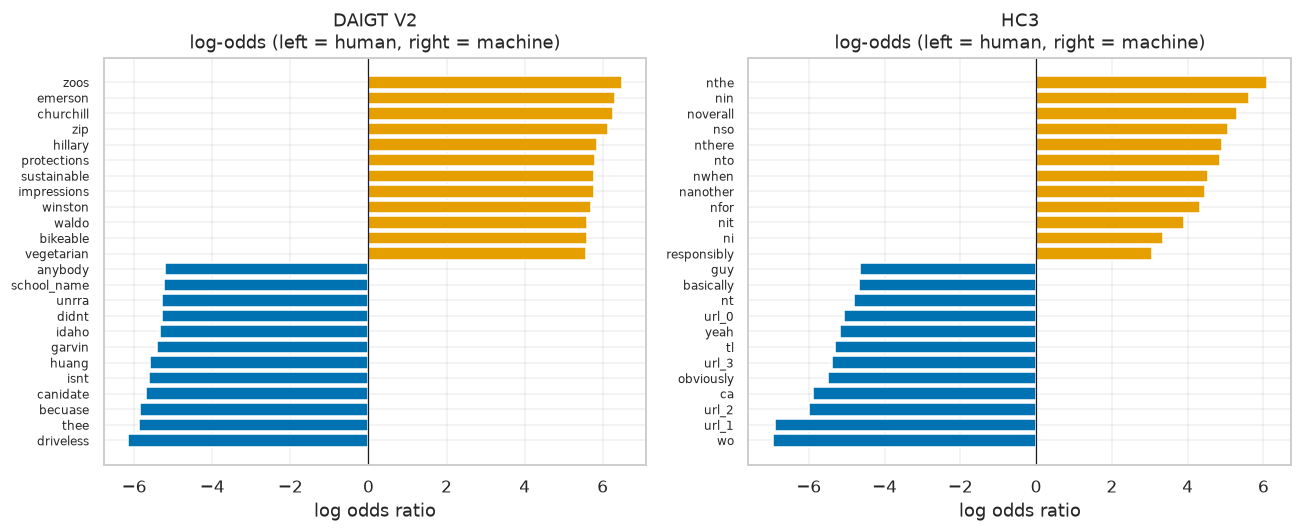

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (tag, name) in zip(axes, DATASETS.items()):
    df = data[tag].loc[splits[tag]['train']]
    cv = CountVectorizer(max_features=4000, stop_words='english', min_df=5)
    X = cv.fit_transform(df.text.astype(str))
    vocab = np.array(cv.get_feature_names_out())
    y = df.label.values
    # log-odds of a term appearing in machine text versus human text
    p1 = np.asarray(X[y == 1].sum(0)).ravel() + 1.0
    p0 = np.asarray(X[y == 0].sum(0)).ravel() + 1.0
    lor = np.log((p1 / p1.sum()) / (p0 / p0.sum()))
    order = np.argsort(lor)
    pick = np.concatenate([order[:12], order[-12:]])
    colors = [PALETTE[0]] * 12 + [PALETTE[1]] * 12
    ax.barh(range(len(pick)), lor[pick], color=colors)
    ax.set_yticks(range(len(pick))); ax.set_yticklabels(vocab[pick], fontsize=8)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_title(f'{name}\nlog-odds (left = human, right = machine)')
    ax.set_xlabel('log odds ratio')
plt.tight_layout(); plt.savefig(FIGDIR / 'discriminative_terms.png'); plt.show()

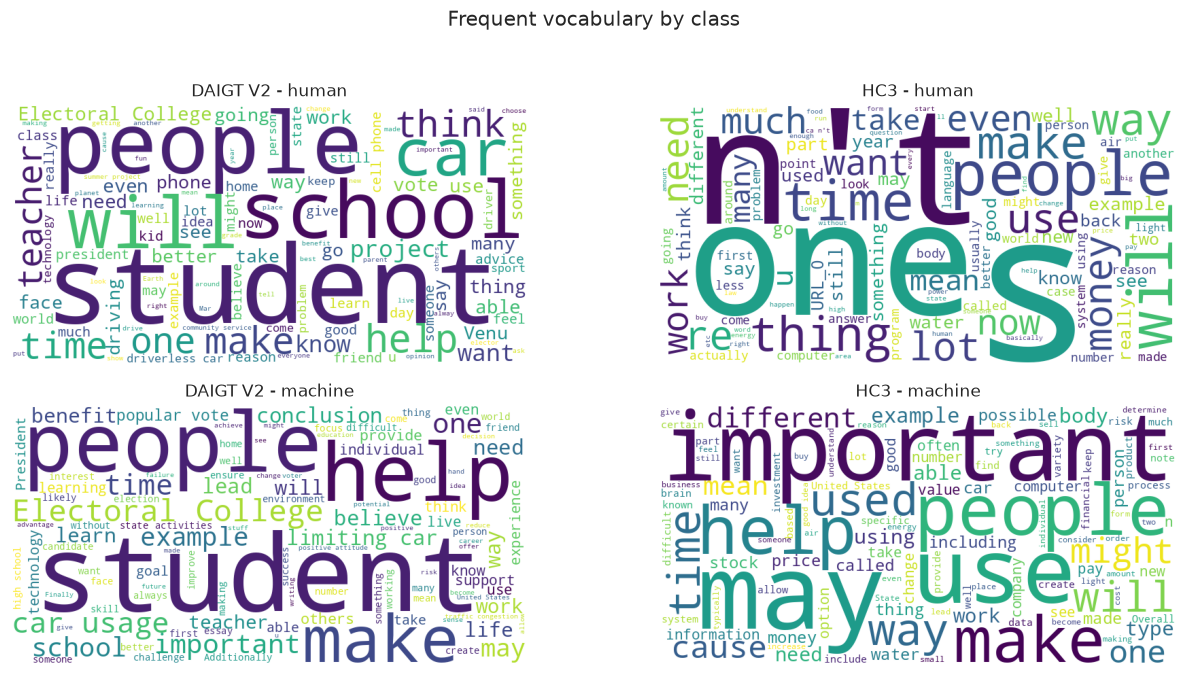

In [7]:
from wordcloud import WordCloud
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for j, (tag, name) in enumerate(DATASETS.items()):
    df = data[tag].loc[splits[tag]['train']]
    for i, lab in enumerate((0, 1)):
        txt = ' '.join(df.loc[df.label == lab, 'text'].astype(str).head(1500))
        wc = WordCloud(width=760, height=380, background_color='white',
                       colormap='viridis', stopwords=None, max_words=110,
                       random_state=SEED).generate(txt)
        axes[i, j].imshow(wc); axes[i, j].axis('off')
        axes[i, j].set_title(f'{name} - {LABELS[lab]}', fontsize=11)
plt.suptitle('Frequent vocabulary by class', y=1.02, fontsize=13)
plt.tight_layout(); plt.savefig(FIGDIR / 'wordclouds.png'); plt.show()

## 4. Preprocessing and feature representations

The classical pipeline lowercases, removes every non-alphabetic character, drops stopwords and lemmatises. Three representations are then built on top of it, plus a character n-gram view that deliberately bypasses the word-level normalisation.

In [8]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

for pkg in ('punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4'):
    try: nltk.download(pkg, quiet=True)
    except Exception: pass

lemmatizer = WordNetLemmatizer()
STOP = set(stopwords.words('english'))

def preprocess(text):
    t = re.sub(r'[^a-z\s]', ' ', str(text).lower())
    toks = [lemmatizer.lemmatize(w) for w in word_tokenize(t)
            if w not in STOP and len(w) > 1]
    return ' '.join(toks)

clean = {}
for tag, name in DATASETS.items():
    cache = WORK / f'clean_{tag}.parquet'
    t0 = time.time()
    if cache.exists():
        clean[tag] = pd.read_parquet(cache)['clean']
        src = 'cache'
    else:
        clean[tag] = data[tag].text.apply(preprocess)
        pd.DataFrame({'clean': clean[tag]}).to_parquet(cache)
        src = 'computed'
    print(f'{name:9s} preprocessing {src:8s} {time.time()-t0:6.1f}s')

ex = data['D2'].text.iloc[0]
print('\nBefore:', ex[:180].replace(chr(10), ' '))
print('After :', clean['D2'].iloc[0][:180])

DAIGT V2  preprocessing cache       0.4s


HC3       preprocessing cache       0.3s

Before: Bond ETFs can drop in value when the dividends are paid out, but the magnitude of the drop will depend on the specific ETF and the prevailing market conditions. It is important to 
After : bond etf drop value dividend paid magnitude drop depend specific etf prevailing market condition important note bond etf like etf subject market fluctuation experience change value


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

MAX_FEATURES = 60000
TREE_FEATURES = 6000     # tree ensembles need a smaller, denser feature space

def build_features(tag):
    tr, te = splits[tag]['train'], splits[tag]['test']
    cl, raw = clean[tag], data[tag].text.astype(str)
    ytr = data[tag].label.values[data[tag].index.get_indexer(tr)]
    yte = data[tag].label.values[data[tag].index.get_indexer(te)]
    reps = {}
    for rep, Vec, kw, source in [
        ('BoW',      CountVectorizer, dict(max_features=MAX_FEATURES), cl),
        ('TF-IDF',   TfidfVectorizer, dict(max_features=MAX_FEATURES), cl),
        ('char3-5',  TfidfVectorizer, dict(analyzer='char_wb', ngram_range=(3, 5),
                                           max_features=MAX_FEATURES), raw),
        ('TF-IDF-s', TfidfVectorizer, dict(max_features=TREE_FEATURES), cl),
    ]:
        v = Vec(**kw)
        reps[rep] = (v.fit_transform(source.loc[tr]), v.transform(source.loc[te]), v)
    return reps, ytr, yte

FEATURES, Y = {}, {}
for tag, name in DATASETS.items():
    t0 = time.time()
    reps, ytr, yte = build_features(tag)
    FEATURES[tag], Y[tag] = reps, (ytr, yte)
    dims = {k: v[0].shape[1] for k, v in reps.items()}
    print(f'{name:9s} {time.time()-t0:5.1f}s  dims={dims}')

DAIGT V2   35.7s  dims={'BoW': 47637, 'TF-IDF': 47637, 'char3-5': 60000, 'TF-IDF-s': 6000}


HC3        23.2s  dims={'BoW': 47359, 'TF-IDF': 47359, 'char3-5': 60000, 'TF-IDF-s': 6000}


## 5. Model sweep

Twelve classical families are evaluated. Linear and Naive Bayes models run on the full sparse feature space. Tree ensembles and the neural network run on a reduced feature space, because they do not scale to tens of thousands of sparse dimensions.

Where a family exposes a choice of solver or criterion, each option is evaluated as a separate configuration, which is what answers the "best optimizer" question for classical models.

In [10]:
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, ComplementNB
from sklearn.linear_model import (LogisticRegression, SGDClassifier,
                                  RidgeClassifier, PassiveAggressiveClassifier)
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              AdaBoostClassifier)
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier

SPARSE_REPS = ['BoW', 'TF-IDF', 'char3-5']
DENSE_REP   = 'TF-IDF-s'

# (display name, constructor, which representations, how to obtain a ranking score)
ZOO = [
    ('MultinomialNB',      lambda: MultinomialNB(),                                   SPARSE_REPS, 'proba'),
    ('BernoulliNB',        lambda: BernoulliNB(),                                     SPARSE_REPS, 'proba'),
    ('ComplementNB',       lambda: ComplementNB(),                                    SPARSE_REPS, 'proba'),
    ('LogReg [lbfgs]',     lambda: LogisticRegression(max_iter=2000, solver='lbfgs',     random_state=SEED), SPARSE_REPS, 'proba'),
    ('LogReg [liblinear]', lambda: LogisticRegression(max_iter=2000, solver='liblinear', random_state=SEED), SPARSE_REPS, 'proba'),
    ('LogReg [saga]',      lambda: LogisticRegression(max_iter=2000, solver='saga',      random_state=SEED), ['TF-IDF'],  'proba'),
    ('LinearSVC',          lambda: LinearSVC(max_iter=20000, random_state=SEED),       SPARSE_REPS, 'decision'),
    ('SGD [hinge]',        lambda: SGDClassifier(loss='hinge', random_state=SEED),      SPARSE_REPS, 'decision'),
    ('SGD [log_loss]',     lambda: SGDClassifier(loss='log_loss', random_state=SEED),   SPARSE_REPS, 'proba'),
    ('SGD [modified_huber]', lambda: SGDClassifier(loss='modified_huber', random_state=SEED), ['TF-IDF'], 'proba'),
    ('RidgeClassifier',    lambda: RidgeClassifier(random_state=SEED),                 SPARSE_REPS, 'decision'),
    ('PassiveAggressive',  lambda: PassiveAggressiveClassifier(max_iter=2000, random_state=SEED), ['TF-IDF'], 'decision'),
    ('DecisionTree [gini]',    lambda: DecisionTreeClassifier(criterion='gini', random_state=SEED),    [DENSE_REP], 'proba'),
    ('DecisionTree [entropy]', lambda: DecisionTreeClassifier(criterion='entropy', random_state=SEED), [DENSE_REP], 'proba'),
    ('RandomForest',       lambda: RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED), [DENSE_REP], 'proba'),
    ('ExtraTrees',         lambda: ExtraTreesClassifier(n_estimators=300, n_jobs=-1, random_state=SEED),   [DENSE_REP], 'proba'),
    ('AdaBoost',           lambda: AdaBoostClassifier(n_estimators=200, random_state=SEED),               [DENSE_REP], 'proba'),
    ('LightGBM',           lambda: LGBMClassifier(n_estimators=400, verbose=-1, random_state=SEED),       [DENSE_REP], 'proba'),
    ('MLP [adam]',         lambda: MLPClassifier(hidden_layer_sizes=(128,), max_iter=40, solver='adam', random_state=SEED), [DENSE_REP], 'proba'),
    ('MLP [sgd]',          lambda: MLPClassifier(hidden_layer_sizes=(128,), max_iter=40, solver='sgd',  random_state=SEED), [DENSE_REP], 'proba'),
]
print(f'{len(ZOO)} configurations x representations x {len(DATASETS)} datasets')

20 configurations x representations x 2 datasets


In [11]:
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             roc_auc_score, average_precision_score, confusion_matrix)

def score_all(y, pred, s):
    acc = accuracy_score(y, pred)
    pw, rw, fw, _ = precision_recall_fscore_support(y, pred, average='weighted', zero_division=0)
    pm, rm, fm, _ = precision_recall_fscore_support(y, pred, average='macro', zero_division=0)
    per = precision_recall_fscore_support(y, pred, average=None, labels=[0, 1], zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {
        'accuracy': acc, 'error_rate': 1 - acc,
        'precision_w': pw, 'recall_w': rw, 'f1_weighted': fw,
        'precision_m': pm, 'recall_m': rm, 'f1_macro': fm,
        'f1_human': per[2][0], 'f1_machine': per[2][1],
        'precision_human': per[0][0], 'recall_human': per[1][0],
        'precision_machine': per[0][1], 'recall_machine': per[1][1],
        'roc_auc': roc_auc_score(y, s), 'pr_auc': average_precision_score(y, s),
        'specificity': tn / max(tn + fp, 1), 'fpr': fp / max(tn + fp, 1),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
    }

results, SCORES, FITTED = [], {}, {}
for tag, name in DATASETS.items():
    ytr, yte = Y[tag]
    for mname, build, reps, kind in ZOO:
        for rep in reps:
            Xtr, Xte, vec = FEATURES[tag][rep]
            try:
                t0 = time.time()
                clf = build().fit(Xtr, ytr)
                fit_s = time.time() - t0
                pred = clf.predict(Xte)
                s = clf.predict_proba(Xte)[:, 1] if kind == 'proba' else clf.decision_function(Xte)
                m = score_all(yte, pred, s)
                m.update({'dataset': name, 'model': mname, 'representation': rep,
                          'fit_seconds': round(fit_s, 2), 'n_features': Xtr.shape[1]})
                # training-set score, so the train/test gap can be read later
                m['train_f1'] = precision_recall_fscore_support(
                    ytr, clf.predict(Xtr), average='weighted', zero_division=0)[2]
                results.append(m)
                SCORES[(name, mname, rep)] = s
                FITTED[(name, mname, rep)] = (clf, vec)
                print(f'  {name:9s} {mname:22s} {rep:9s} F1={m["f1_weighted"]:.4f} '
                      f'AUC={m["roc_auc"]:.4f} ({fit_s:5.1f}s)')
            except Exception as e:
                print(f'  {name:9s} {mname:22s} {rep:9s} FAILED: {type(e).__name__}: {e}')

R = pd.DataFrame(results)
R['overfit_gap'] = R.train_f1 - R.f1_weighted
print(f'\ncompleted {len(R)} model-representation configurations')

  DAIGT V2  MultinomialNB          BoW       F1=0.9591 AUC=0.9918 (  0.0s)
  DAIGT V2  MultinomialNB          TF-IDF    F1=0.9577 AUC=0.9915 (  0.0s)


  DAIGT V2  MultinomialNB          char3-5   F1=0.9544 AUC=0.9909 (  0.1s)
  DAIGT V2  BernoulliNB            BoW       F1=0.9570 AUC=0.9903 (  0.0s)
  DAIGT V2  BernoulliNB            TF-IDF    F1=0.9570 AUC=0.9903 (  0.0s)


  DAIGT V2  BernoulliNB            char3-5   F1=0.9396 AUC=0.9810 (  0.4s)
  DAIGT V2  ComplementNB           BoW       F1=0.9591 AUC=0.9918 (  0.0s)
  DAIGT V2  ComplementNB           TF-IDF    F1=0.9581 AUC=0.9915 (  0.0s)


  DAIGT V2  ComplementNB           char3-5   F1=0.9544 AUC=0.9909 (  0.1s)


  DAIGT V2  LogReg [lbfgs]         BoW       F1=0.9893 AUC=0.9988 (  5.5s)


...

  HC3       ExtraTrees             TF-IDF-s  F1=0.9479 AUC=0.9879 ( 19.3s)


  HC3       AdaBoost               TF-IDF-s  F1=0.8919 AUC=0.9616 ( 30.7s)


  HC3       LightGBM               TF-IDF-s  F1=0.9652 AUC=0.9940 ( 16.5s)


  HC3       MLP [adam]             TF-IDF-s  F1=0.9106 AUC=0.9727 ( 65.8s)


  HC3       MLP [sgd]              TF-IDF-s  F1=0.8588 AUC=0.9344 ( 61.6s)

completed 76 model-representation configurations


## 6. Master comparison table

In [12]:
show = ['dataset', 'model', 'representation', 'accuracy', 'precision_w', 'recall_w',
        'f1_weighted', 'f1_macro', 'roc_auc', 'pr_auc', 'fpr', 'fit_seconds']
master = R[show].sort_values(['dataset', 'f1_weighted'], ascending=[True, False]).reset_index(drop=True)
pd.set_option('display.max_rows', 250, 'display.width', 220)
display(master.style.format({c: '{:.4f}' for c in
        ['accuracy','precision_w','recall_w','f1_weighted','f1_macro','roc_auc','pr_auc','fpr']})
       .background_gradient(subset=['f1_weighted','roc_auc'], cmap='Greens'))
master.to_csv(PROJECT / 'notebook_model_comparison.csv', index=False)
print('saved -> notebook_model_comparison.csv')

,dataset,model,representation,accuracy,precision_w,recall_w,f1_weighted,f1_macro,roc_auc,pr_auc,fpr,fit_seconds
0,DAIGT V2,RidgeClassifier,char3-5,0.9941,0.9942,0.9941,0.9941,0.9941,0.9995,0.9996,0.0009,7.790000
1,DAIGT V2,LinearSVC,char3-5,0.9936,0.9936,0.9936,0.9936,0.9936,0.9995,0.9996,0.0023,1.040000
2,DAIGT V2,LightGBM,TF-IDF-s,0.9926,0.9926,0.9926,0.9926,0.9926,0.9995,0.9995,0.0011,26.280000
3,DAIGT V2,SGD [hinge],char3-5,0.9919,0.9919,0.9919,0.9919,0.9919,0.9991,0.9993,0.0031,0.420000
4,DAIGT V2,MLP [adam],TF-IDF-s,0.9910,0.9911,0.9910,0.9910,0.9910,0.9992,0.9994,0.0037,39.340000
5,DAIGT V2,LinearSVC,TF-IDF,0.9910,0.9911,0.9910,0.9910,0.9910,0.9992,0.9994,0.0034,0.100000
6,DAIGT V2,RidgeClassifier,TF-IDF,0.9910,0.9911,0.9910,0.9910,0.9910,0.9992,0.9994,0.0017,0.660000
7,DAIGT V2,PassiveAggressive,TF-IDF,0.9907,0.9907,0.9907,0.9907,0.9907,0.9991,0.9992,0.0060,0.110000
8,DAIGT V2,SGD [modified_huber],TF-IDF,0.9894,0.9895,0.9894,0.9894,0.9894,0.9991,0.9992,0.0051,0.060000
9,DAIGT V2,LogReg [lbfgs],BoW,0.9893,0.9893,0.9893,0.9893,0.9893,0.9988,0.9990,0.0065,5.510000


saved -> notebook_model_comparison.csv


### 6.1 Best configuration per dataset, and best per family

In [13]:
for tag, name in DATASETS.items():
    sub = R[R.dataset == name].sort_values('f1_weighted', ascending=False)
    b = sub.iloc[0]
    print(f'\n=== {name} ===')
    print(f'  best overall : {b.model} + {b.representation}')
    print(f'    F1 {b.f1_weighted:.4f} | acc {b.accuracy:.4f} | AUC {b.roc_auc:.4f} '
          f'| FPR {b.fpr:.4f} | fit {b.fit_seconds}s')
    print('  best representation per family:')
    for fam, g in sub.groupby('model'):
        t = g.sort_values('f1_weighted', ascending=False).iloc[0]
        print(f'    {fam:22s} {t.representation:9s} F1={t.f1_weighted:.4f}')


=== DAIGT V2 ===
  best overall : RidgeClassifier + char3-5
    F1 0.9941 | acc 0.9941 | AUC 0.9995 | FPR 0.0009 | fit 7.79s
  best representation per family:
    AdaBoost               TF-IDF-s  F1=0.9626
    BernoulliNB            TF-IDF    F1=0.9570
    ComplementNB           BoW       F1=0.9591
    DecisionTree [entropy] TF-IDF-s  F1=0.9044
    DecisionTree [gini]    TF-IDF-s  F1=0.9124
    ExtraTrees             TF-IDF-s  F1=0.9864
    LightGBM               TF-IDF-s  F1=0.9926
    LinearSVC              char3-5   F1=0.9936
    LogReg [lbfgs]         BoW       F1=0.9893
    LogReg [liblinear]     BoW       F1=0.9893
    LogReg [saga]          TF-IDF    F1=0.9860
    MLP [adam]             TF-IDF-s  F1=0.9910
    MLP [sgd]              TF-IDF-s  F1=0.9397
    MultinomialNB          BoW       F1=0.9591
    PassiveAggressive      TF-IDF    F1=0.9907
    RandomForest           TF-IDF-s  F1=0.9827
    RidgeClassifier        char3-5   F1=0.9941
    SGD [hinge]            char3-5   F1=0

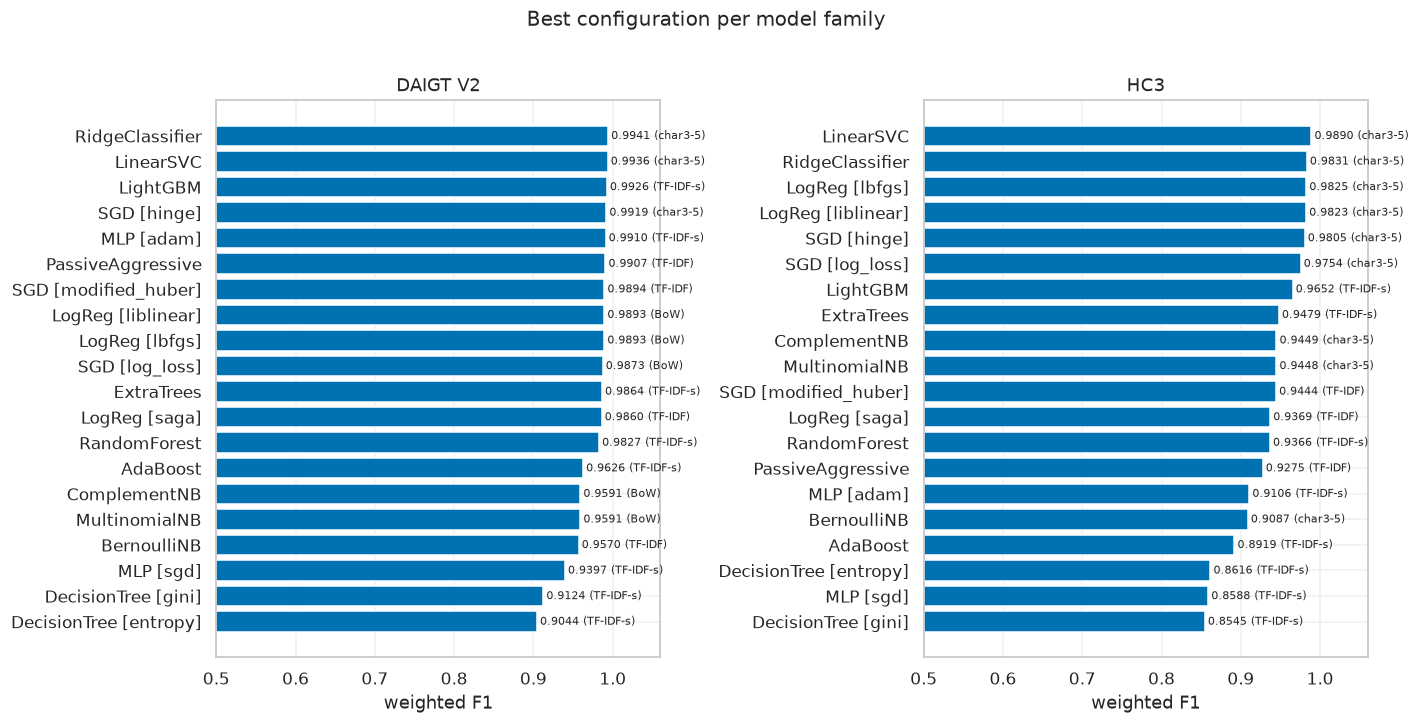

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), sharex=True)
for ax, (tag, name) in zip(axes, DATASETS.items()):
    sub = (R[R.dataset == name].sort_values('f1_weighted', ascending=False)
             .groupby('model', as_index=False).first()
             .sort_values('f1_weighted'))
    ax.barh(sub.model, sub.f1_weighted, color=PALETTE[0])
    for i, (v, r) in enumerate(zip(sub.f1_weighted, sub.representation)):
        ax.text(v + 0.004, i, f'{v:.4f} ({r})', va='center', fontsize=7.5)
    ax.set_xlim(0.5, 1.06); ax.set_title(name); ax.set_xlabel('weighted F1')
plt.suptitle('Best configuration per model family', y=1.01, fontsize=13)
plt.tight_layout(); plt.savefig(FIGDIR / 'model_ranking.png'); plt.show()

### 6.2 Which solver wins, holding the model family fixed

In [15]:
solver_fams = {'LogReg': ['LogReg [lbfgs]', 'LogReg [liblinear]', 'LogReg [saga]'],
               'SGD':    ['SGD [hinge]', 'SGD [log_loss]', 'SGD [modified_huber]'],
               'MLP':    ['MLP [adam]', 'MLP [sgd]'],
               'DecisionTree': ['DecisionTree [gini]', 'DecisionTree [entropy]']}
rows = []
for fam, members in solver_fams.items():
    for name in DATASETS.values():
        sub = R[(R.dataset == name) & (R.model.isin(members))]
        if sub.empty: continue
        best = sub.sort_values('f1_weighted', ascending=False).iloc[0]
        rows.append({'family': fam, 'dataset': name, 'best option': best.model,
                     'representation': best.representation,
                     'F1': round(best.f1_weighted, 4),
                     'spread across options': round(sub.f1_weighted.max() - sub.f1_weighted.min(), 4)})
display(pd.DataFrame(rows).set_index(['family', 'dataset']))

best option representation      F1  spread across options
family       dataset                                                                       
LogReg       DAIGT V2          LogReg [lbfgs]            BoW  0.9893                 0.0036
             HC3               LogReg [lbfgs]        char3-5  0.9825                 0.0459
SGD          DAIGT V2             SGD [hinge]        char3-5  0.9919                 0.0100
             HC3                  SGD [hinge]        char3-5  0.9805                 0.0581
MLP          DAIGT V2              MLP [adam]       TF-IDF-s  0.9910                 0.0513
             HC3                   MLP [adam]       TF-IDF-s  0.9106                 0.0518
DecisionTree DAIGT V2     DecisionTree [gini]       TF-IDF-s  0.9124                 0.0080
             HC3       DecisionTree [entropy]       TF-IDF-s  0.8616                 0.0072

## 7. Confusion matrices, ROC and precision-recall curves

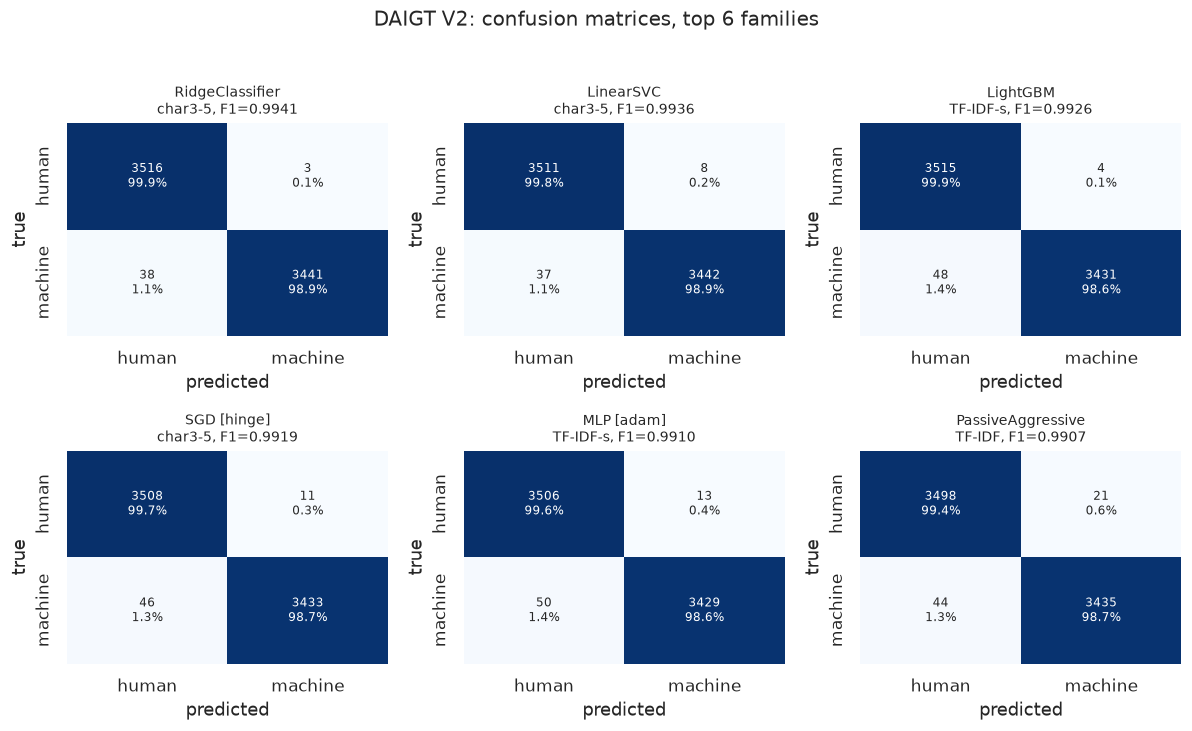

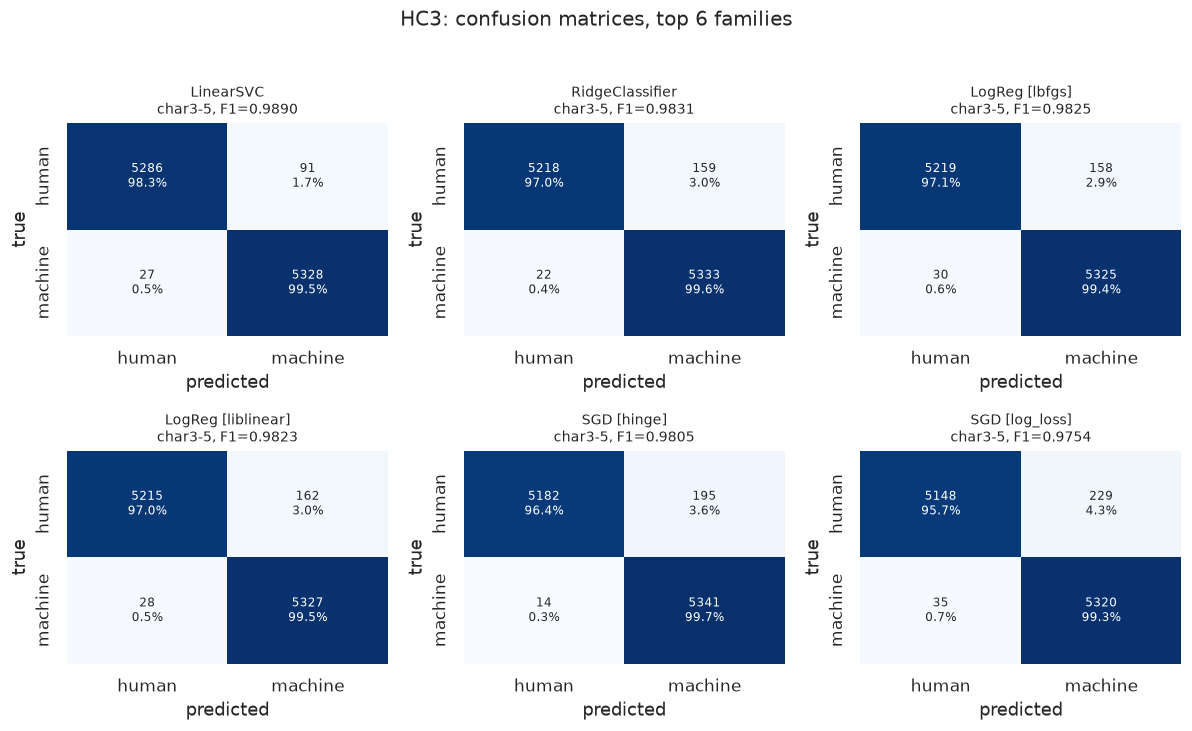

In [16]:
TOPN = 6
def top_configs(name, n=TOPN):
    return (R[R.dataset == name].sort_values('f1_weighted', ascending=False)
              .groupby('model', as_index=False).first()
              .sort_values('f1_weighted', ascending=False).head(n))

for tag, name in DATASETS.items():
    top = top_configs(name)
    fig, axes = plt.subplots(2, 3, figsize=(11, 6.5))
    for ax, (_, r) in zip(axes.ravel(), top.iterrows()):
        cm = np.array([[r.TN, r.FP], [r.FN, r.TP]], float)
        cmn = cm / cm.sum(1, keepdims=True)
        sns.heatmap(cmn, annot=np.array([[f'{int(cm[i,j])}\n{cmn[i,j]*100:.1f}%'
                                          for j in range(2)] for i in range(2)]),
                    fmt='', cmap='Blues', vmin=0, vmax=1, cbar=False, ax=ax,
                    xticklabels=['human','machine'], yticklabels=['human','machine'],
                    annot_kws={'fontsize': 8})
        ax.set_title(f'{r.model}\n{r.representation}, F1={r.f1_weighted:.4f}', fontsize=9)
        ax.set_xlabel('predicted'); ax.set_ylabel('true')
    plt.suptitle(f'{name}: confusion matrices, top {TOPN} families', y=1.02, fontsize=13)
    plt.tight_layout(); plt.savefig(FIGDIR / f'confusion_{tag}.png'); plt.show()

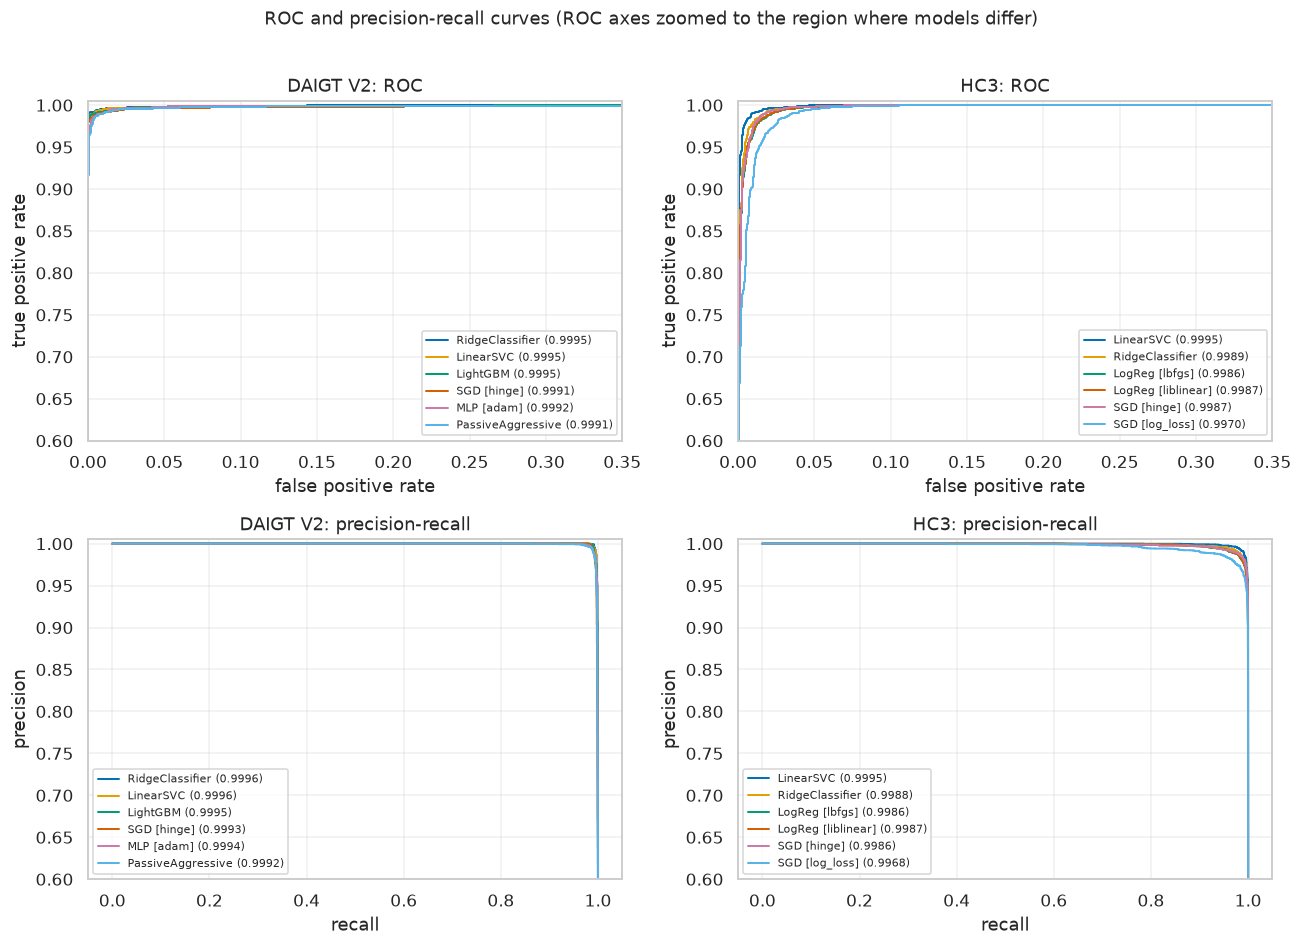

In [17]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(2, 2, figsize=(12, 8.5))
for j, (tag, name) in enumerate(DATASETS.items()):
    _, yte = Y[tag]
    top = top_configs(name)
    for k, (_, r) in enumerate(top.iterrows()):
        s = SCORES[(name, r.model, r.representation)]
        fpr, tpr, _ = roc_curve(yte, s)
        axes[0, j].plot(fpr, tpr, lw=1.3, color=PALETTE[k % len(PALETTE)],
                        label=f'{r.model} ({r.roc_auc:.4f})')
        pr, rc, _ = precision_recall_curve(yte, s)
        axes[1, j].plot(rc, pr, lw=1.3, color=PALETTE[k % len(PALETTE)],
                        label=f'{r.model} ({r.pr_auc:.4f})')
    axes[0, j].plot([0, 1], [0, 1], 'k--', lw=0.7)
    axes[0, j].set_title(f'{name}: ROC'); axes[0, j].set_xlabel('false positive rate')
    axes[0, j].set_ylabel('true positive rate'); axes[0, j].legend(fontsize=7, loc='lower right')
    axes[0, j].set_xlim(0, 0.35); axes[0, j].set_ylim(0.6, 1.005)
    axes[1, j].set_title(f'{name}: precision-recall'); axes[1, j].set_xlabel('recall')
    axes[1, j].set_ylabel('precision'); axes[1, j].legend(fontsize=7, loc='lower left')
    axes[1, j].set_ylim(0.6, 1.005)
plt.suptitle('ROC and precision-recall curves (ROC axes zoomed to the region where models differ)',
             y=1.01, fontsize=12)
plt.tight_layout(); plt.savefig(FIGDIR / 'roc_pr_curves.png'); plt.show()

## 8. Feature importance and SHAP

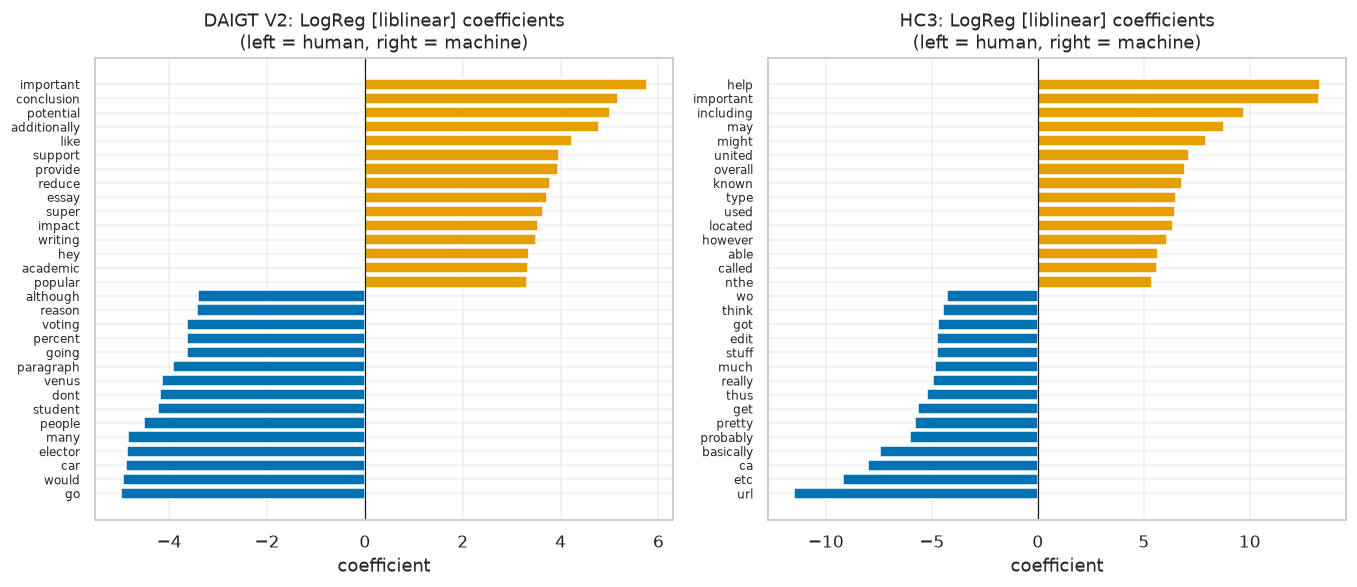

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.5))
for ax, (tag, name) in zip(axes, DATASETS.items()):
    key = (name, 'LogReg [liblinear]', 'TF-IDF')
    if key not in FITTED:
        key = [k for k in FITTED if k[0] == name and 'LogReg' in k[1]][0]
    clf, vec = FITTED[key]
    coef = clf.coef_.ravel()
    vocab = np.array(vec.get_feature_names_out())
    order = np.argsort(coef)
    pick = np.concatenate([order[:15], order[-15:]])
    ax.barh(range(len(pick)), coef[pick],
            color=[PALETTE[0]] * 15 + [PALETTE[1]] * 15)
    ax.set_yticks(range(len(pick))); ax.set_yticklabels(vocab[pick], fontsize=8)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_title(f'{name}: {key[1]} coefficients\n(left = human, right = machine)')
    ax.set_xlabel('coefficient')
plt.tight_layout(); plt.savefig(FIGDIR / 'feature_importance_linear.png'); plt.show()

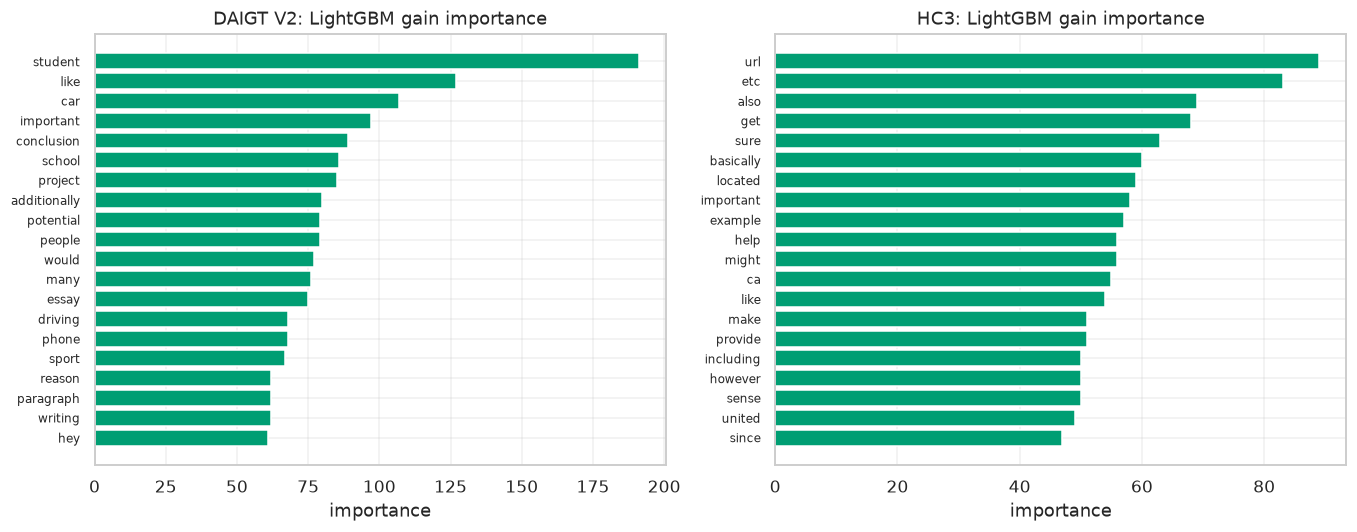

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
for ax, (tag, name) in zip(axes, DATASETS.items()):
    key = (name, 'LightGBM', DENSE_REP)
    if key not in FITTED: continue
    clf, vec = FITTED[key]
    imp = clf.feature_importances_
    vocab = np.array(vec.get_feature_names_out())
    top = np.argsort(imp)[-20:]
    ax.barh(range(len(top)), imp[top], color=PALETTE[2])
    ax.set_yticks(range(len(top))); ax.set_yticklabels(vocab[top], fontsize=8)
    ax.set_title(f'{name}: LightGBM gain importance'); ax.set_xlabel('importance')
plt.tight_layout(); plt.savefig(FIGDIR / 'feature_importance_lgbm.png'); plt.show()

DAIGT V2: SHAP over 400 test documents, 6000 features


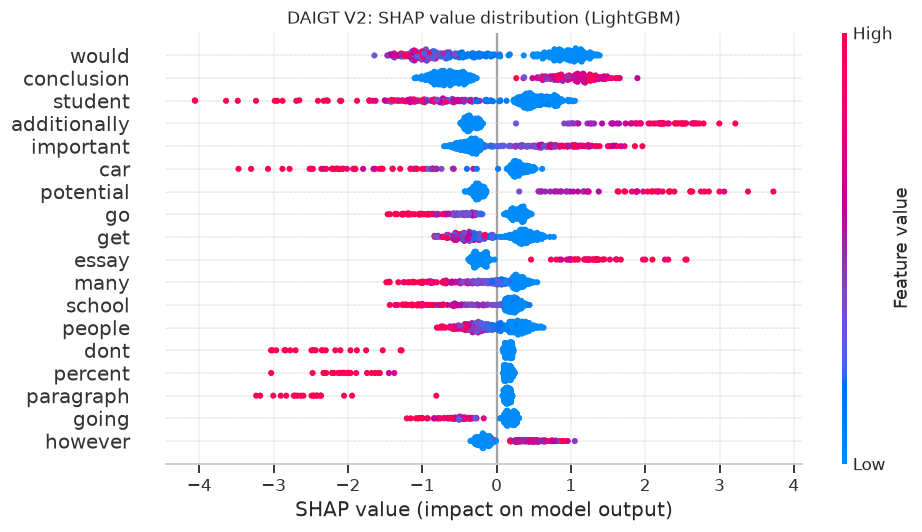

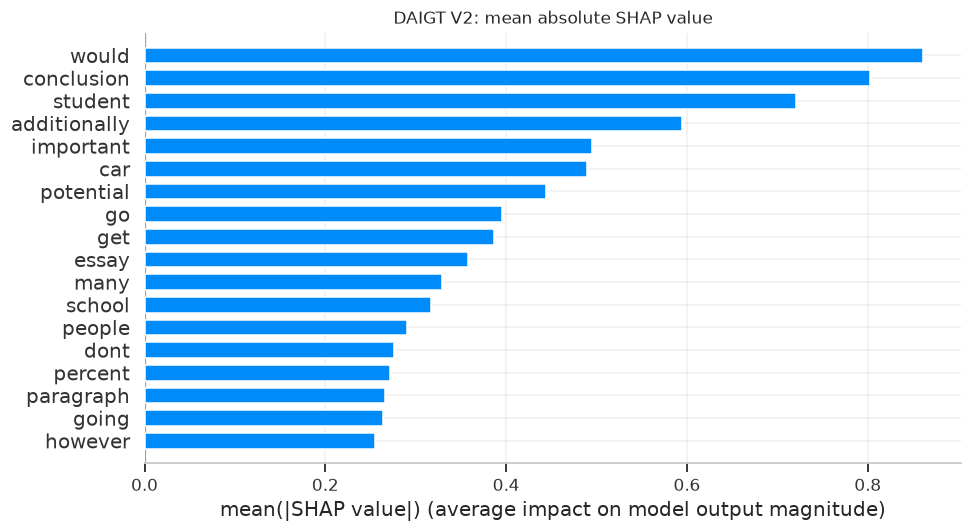

HC3: SHAP over 400 test documents, 6000 features


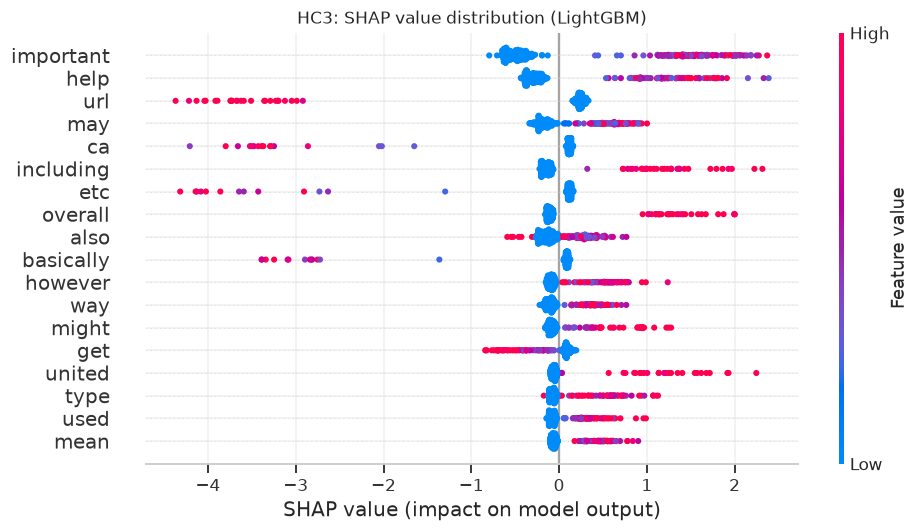

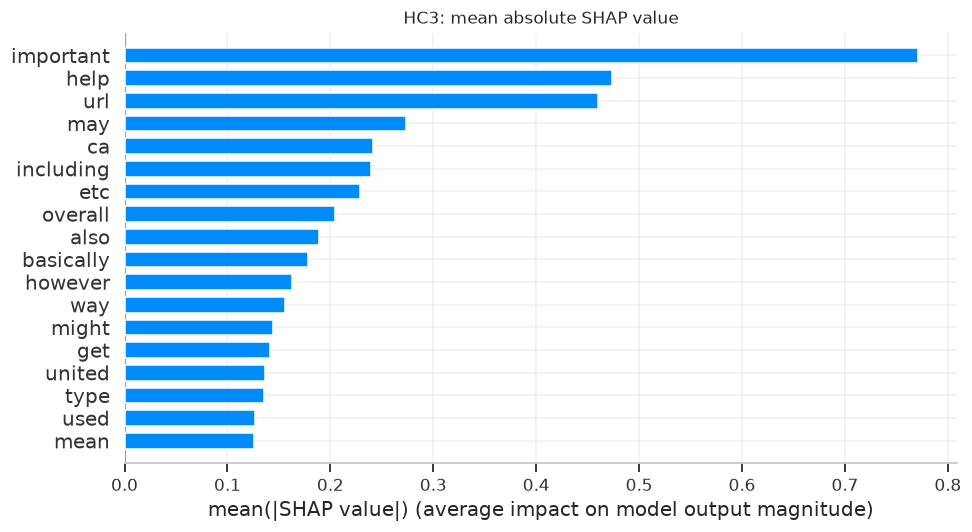

In [20]:
import shap
SHAP_N = 400          # explanation sample; TreeSHAP is exact but scales with rows
for tag, name in DATASETS.items():
    key = (name, 'LightGBM', DENSE_REP)
    if key not in FITTED:
        print(f'{name}: LightGBM unavailable, skipping SHAP'); continue
    clf, vec = FITTED[key]
    Xte = FEATURES[tag][DENSE_REP][1]
    idx = np.random.RandomState(SEED).choice(Xte.shape[0], min(SHAP_N, Xte.shape[0]), replace=False)
    Xs = Xte[idx].toarray()
    expl = shap.TreeExplainer(clf)
    sv = expl.shap_values(Xs)
    if isinstance(sv, list): sv = sv[1]
    print(f'{name}: SHAP over {Xs.shape[0]} test documents, {Xs.shape[1]} features')
    shap.summary_plot(sv, Xs, feature_names=vec.get_feature_names_out(),
                      max_display=18, show=False, plot_size=(9, 5))
    plt.title(f'{name}: SHAP value distribution (LightGBM)', fontsize=11)
    plt.tight_layout(); plt.savefig(FIGDIR / f'shap_summary_{tag}.png'); plt.show()

    shap.summary_plot(sv, Xs, feature_names=vec.get_feature_names_out(),
                      plot_type='bar', max_display=18, show=False, plot_size=(9, 5))
    plt.title(f'{name}: mean absolute SHAP value', fontsize=11)
    plt.tight_layout(); plt.savefig(FIGDIR / f'shap_bar_{tag}.png'); plt.show()

## 9. Overfitting diagnostics

Three checks. The train-versus-test gap per configuration, learning curves as training data grows, and stratified cross-validation on the training partition so the held-out test set is never used for model selection.

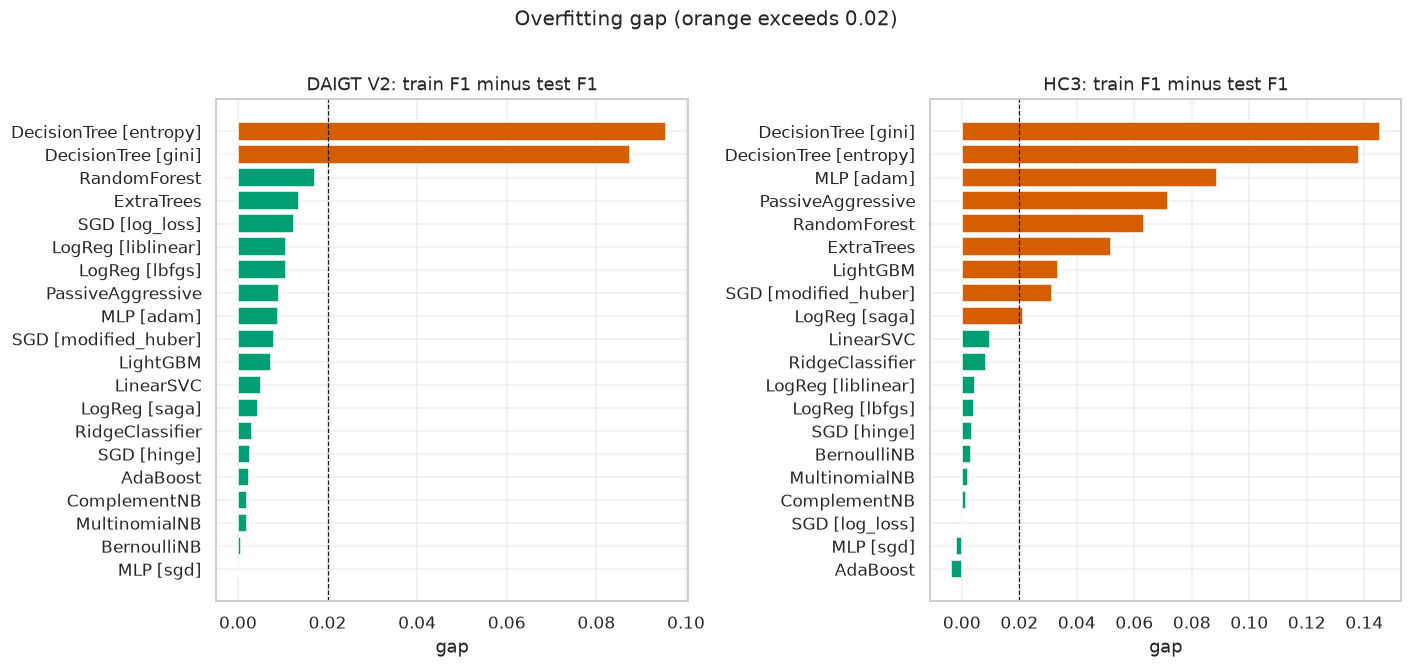

,dataset,model,representation,train_f1,f1_weighted,overfit_gap
68,HC3,DecisionTree [gini],TF-IDF-s,0.9999,0.8545,0.1454
69,HC3,DecisionTree [entropy],TF-IDF-s,0.9999,0.8616,0.1383
64,HC3,RidgeClassifier,BoW,0.9954,0.8867,0.1087
31,DAIGT V2,DecisionTree [entropy],TF-IDF-s,1.0000,0.9044,0.0956
74,HC3,MLP [adam],TF-IDF-s,0.9995,0.9106,0.0889
30,DAIGT V2,DecisionTree [gini],TF-IDF-s,1.0000,0.9124,0.0876
67,HC3,PassiveAggressive,TF-IDF,0.9994,0.9275,0.0719
70,HC3,RandomForest,TF-IDF-s,0.9999,0.9366,0.0633
57,HC3,SGD [hinge],BoW,0.9922,0.9337,0.0585
60,HC3,SGD [log_loss],BoW,0.9868,0.9333,0.0535


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, (tag, name) in zip(axes, DATASETS.items()):
    sub = (R[R.dataset == name].sort_values('f1_weighted', ascending=False)
             .groupby('model', as_index=False).first().sort_values('overfit_gap'))
    colors = [PALETTE[3] if g > 0.02 else PALETTE[2] for g in sub.overfit_gap]
    ax.barh(sub.model, sub.overfit_gap, color=colors)
    ax.axvline(0.02, color='k', ls='--', lw=0.8)
    ax.set_title(f'{name}: train F1 minus test F1'); ax.set_xlabel('gap')
plt.suptitle('Overfitting gap (orange exceeds 0.02)', y=1.01, fontsize=13)
plt.tight_layout(); plt.savefig(FIGDIR / 'overfitting_gap.png'); plt.show()

display(R.sort_values('overfit_gap', ascending=False)
         [['dataset','model','representation','train_f1','f1_weighted','overfit_gap']]
         .head(12).style.format({'train_f1':'{:.4f}','f1_weighted':'{:.4f}','overfit_gap':'{:.4f}'}))

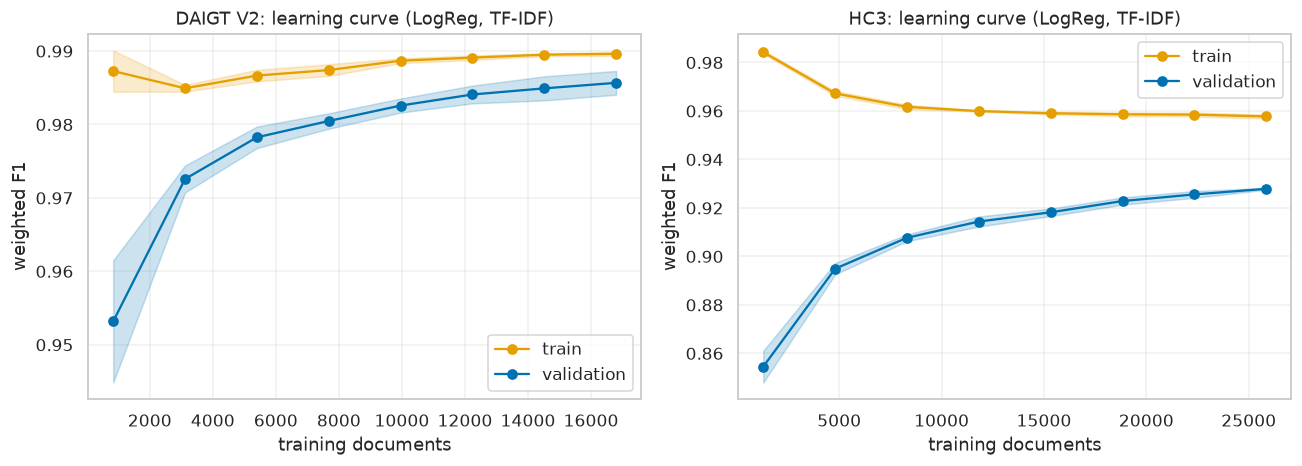

In [22]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, (tag, name) in zip(axes, DATASETS.items()):
    Xtr, _, _ = FEATURES[tag]['TF-IDF']
    ytr, _ = Y[tag]
    sizes, tr_s, te_s = learning_curve(
        LogisticRegression(max_iter=2000, solver='liblinear', random_state=SEED),
        Xtr, ytr, train_sizes=np.linspace(0.05, 1.0, 8), cv=3,
        scoring='f1_weighted', n_jobs=-1, random_state=SEED)
    ax.plot(sizes, tr_s.mean(1), 'o-', color=PALETTE[1], label='train')
    ax.fill_between(sizes, tr_s.mean(1)-tr_s.std(1), tr_s.mean(1)+tr_s.std(1), alpha=0.2, color=PALETTE[1])
    ax.plot(sizes, te_s.mean(1), 'o-', color=PALETTE[0], label='validation')
    ax.fill_between(sizes, te_s.mean(1)-te_s.std(1), te_s.mean(1)+te_s.std(1), alpha=0.2, color=PALETTE[0])
    ax.set_title(f'{name}: learning curve (LogReg, TF-IDF)')
    ax.set_xlabel('training documents'); ax.set_ylabel('weighted F1'); ax.legend()
plt.tight_layout(); plt.savefig(FIGDIR / 'learning_curves.png'); plt.show()

In [23]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

CV_MODELS = ['MultinomialNB', 'LogReg [liblinear]', 'LinearSVC', 'RidgeClassifier']
cv_rows = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for tag, name in DATASETS.items():
    Xtr, _, _ = FEATURES[tag]['TF-IDF']
    ytr, _ = Y[tag]
    for mname, build, reps, _ in ZOO:
        if mname not in CV_MODELS: continue
        sc = cross_val_score(build(), Xtr, ytr, cv=skf, scoring='f1_weighted', n_jobs=-1)
        cv_rows.append({'dataset': name, 'model': mname,
                        'cv mean F1': sc.mean(), 'cv std': sc.std(),
                        'cv min': sc.min(), 'cv max': sc.max(),
                        'held-out test F1': R[(R.dataset==name)&(R.model==mname)&
                                              (R.representation=='TF-IDF')].f1_weighted.iloc[0]})
cv = pd.DataFrame(cv_rows)
display(cv.style.format({c: '{:.4f}' for c in
        ['cv mean F1','cv std','cv min','cv max','held-out test F1']}))
print('\nA cross-validation mean close to the held-out test score indicates the test set is not atypical.')

,dataset,model,cv mean F1,cv std,cv min,cv max,held-out test F1
0,DAIGT V2,MultinomialNB,0.9552,0.0017,0.9518,0.9563,0.9577
1,DAIGT V2,LogReg [liblinear],0.9867,0.0018,0.9847,0.9893,0.9860
2,DAIGT V2,LinearSVC,0.9922,0.0011,0.9905,0.9936,0.9910
3,DAIGT V2,RidgeClassifier,0.9921,0.0014,0.9897,0.9938,0.9910
4,HC3,MultinomialNB,0.8607,0.0032,0.8555,0.8643,0.8670
5,HC3,LogReg [liblinear],0.9309,0.0021,0.9270,0.9328,0.9369
6,HC3,LinearSVC,0.9380,0.0011,0.9362,0.9393,0.9449
7,HC3,RidgeClassifier,0.9357,0.0012,0.9334,0.9367,0.9404



A cross-validation mean close to the held-out test score indicates the test set is not atypical.


## 10. Fine-tuned transformer comparison

BERT and DeBERTa were fine-tuned separately, since training them inside a notebook is impractical. Results are read from their saved run records. Each number belongs to the checkpoint that was actually saved, not to the best value seen anywhere in the hyperparameter grid.

In [24]:
tf_rows = []
for tag, name in DATASETS.items():
    for mk in ('BERT', 'DeBERTa'):
        p = MODELS / f'{tag}_{mk}' / 'run_info.json'
        if not p.exists():
            print(f'  {name} {mk}: no saved run record'); continue
        r = json.load(open(p))
        tf_rows.append({'dataset': name, 'model': mk,
                        'accuracy': r['test']['accuracy'], 'precision_w': r['test']['precision'],
                        'recall_w': r['test']['recall'], 'f1_weighted': r['test']['f1'],
                        'error_rate': round(1 - r['test']['accuracy'], 4),
                        'lr': r['lr'], 'batch': r['batch_size'], 'weight decay': r['weight_decay'],
                        'epochs': r['epochs_run'], 'max_len': r['max_len'],
                        'train_seconds': r['train_seconds'], 'optimizer': 'AdamW'})
T = pd.DataFrame(tf_rows)
display(T.style.format({c: '{:.4f}' for c in ['accuracy','precision_w','recall_w','f1_weighted']}))

,dataset,model,accuracy,precision_w,recall_w,f1_weighted,error_rate,lr,batch,weight decay,epochs,max_len,train_seconds,optimizer
0,DAIGT V2,BERT,0.9916,0.9916,0.9916,0.9916,0.008400,0.000030,32,0.100000,5,128,584.100000,AdamW
1,DAIGT V2,DeBERTa,0.9917,0.9917,0.9917,0.9917,0.008300,0.000030,16,0.010000,3,128,735.000000,AdamW
2,HC3,BERT,0.9916,0.9917,0.9916,0.9916,0.008400,0.000020,16,0.100000,3,128,692.200000,AdamW
3,HC3,DeBERTa,0.9972,0.9972,0.9972,0.9972,0.002800,0.000030,16,0.100000,3,128,1111.300000,AdamW


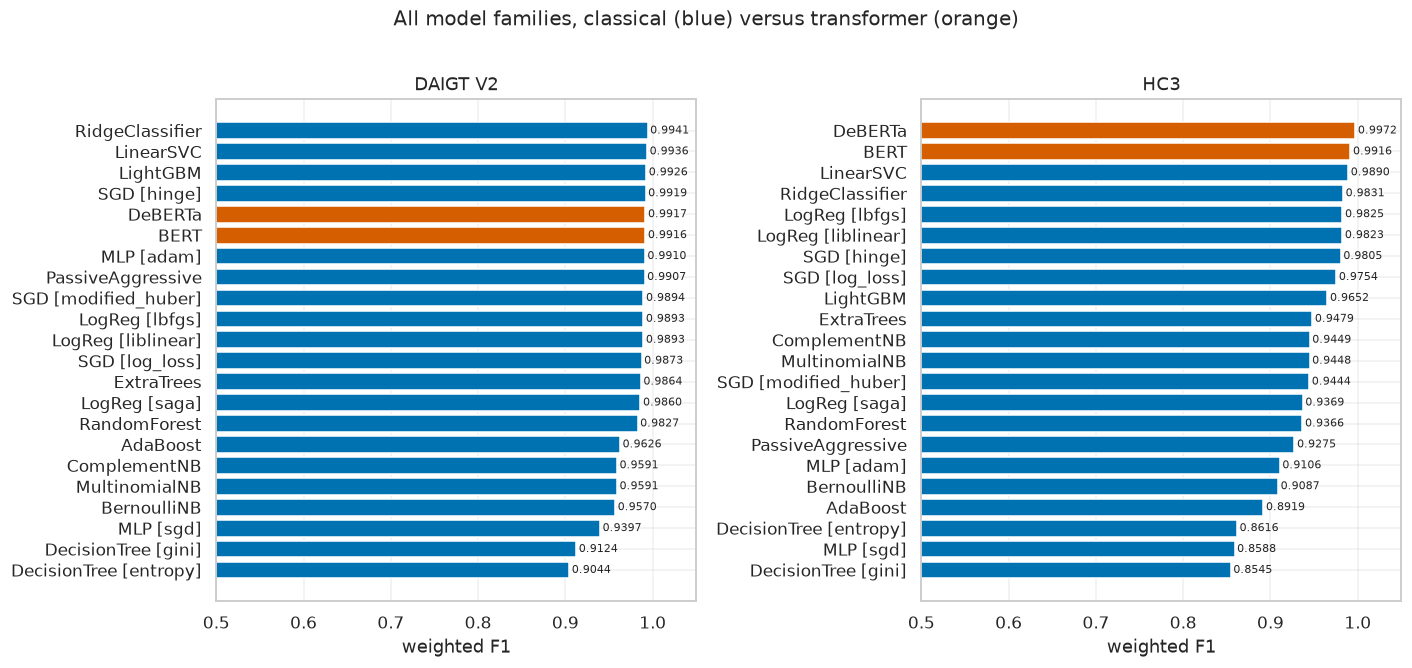

saved -> notebook_all_models_comparison.csv


In [25]:
combined = pd.concat([
    R.assign(kind='classical')[['dataset','model','representation','kind',
                                'accuracy','f1_weighted','f1_macro','roc_auc','error_rate']],
    T.assign(kind='transformer', representation='raw subword',
             f1_macro=np.nan, roc_auc=np.nan)[['dataset','model','representation','kind',
                                'accuracy','f1_weighted','f1_macro','roc_auc','error_rate']],
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, (tag, name) in zip(axes, DATASETS.items()):
    sub = (combined[combined.dataset == name]
             .sort_values('f1_weighted', ascending=False)
             .groupby('model', as_index=False).first()
             .sort_values('f1_weighted'))
    colors = [PALETTE[3] if k == 'transformer' else PALETTE[0] for k in sub.kind]
    ax.barh(sub.model, sub.f1_weighted, color=colors)
    for i, v in enumerate(sub.f1_weighted):
        ax.text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=7.5)
    ax.set_xlim(0.5, 1.05); ax.set_title(name); ax.set_xlabel('weighted F1')
plt.suptitle('All model families, classical (blue) versus transformer (orange)', y=1.01, fontsize=13)
plt.tight_layout(); plt.savefig(FIGDIR / 'classical_vs_transformer.png'); plt.show()

combined.sort_values(['dataset','f1_weighted'], ascending=[True, False]).to_csv(
    PROJECT / 'notebook_all_models_comparison.csv', index=False)
print('saved -> notebook_all_models_comparison.csv')

## 10b. Required submission tables

The two tables specified for this project. Table 1 is the fine-tuning grid over learning rate, batch size and weight decay for both transformers. Table 2 is the final comparison across every model family.

Fixed settings for both transformers, as specified: 5 epochs with early stopping, warmup ratio 0.1, maximum sequence length 128, dropout 0.1, optimiser AdamW.

The ENSEMBLE row is a validation-weighted soft vote over the two transformers, recomputed here from their saved probability arrays.

In [26]:
PROBS = PROJECT / 'paper_scale' / 'probs'
DEPLOYED = {
    ('D1','BERT'):    'full_D1_BERT_lr3e-05_bs32_wd0.1_s42',
    ('D1','DeBERTa'): 'full_D1_DeBERTa_lr3e-05_bs16_wd0.01_s42',
    ('D2','BERT'):    'full_D2_BERT_lr2e-05_bs16_wd0.1_s42',
    ('D2','DeBERTa'): 'full_D2_DeBERTa_lr3e-05_bs16_wd0.1_s42',
}

def four(y, pred):
    a = accuracy_score(y, pred)
    p, r, f, _ = precision_recall_fscore_support(y, pred, average='weighted', zero_division=0)
    return a, p, r, f

ens = {}
for tag, name in DATASETS.items():
    got = {}
    for mk in ('BERT','DeBERTa'):
        f = PROBS / (DEPLOYED[(tag,mk)] + '.npz')
        if f.exists():
            z = np.load(f); got[mk] = (z['test_probs'], z['test_labels'])
    if len(got) == 2:
        pb, yb = got['BERT']; pd_, yd = got['DeBERTa']
        assert np.array_equal(yb, yd), 'label vectors differ between the two runs'
        # the mixing weight is chosen on VALIDATION, never on test. Selecting it
        # on test would report an optimistically biased ensemble score.
        vb = np.load(PROBS / (DEPLOYED[(tag,'BERT')] + '.npz'))
        vd = np.load(PROBS / (DEPLOYED[(tag,'DeBERTa')] + '.npz'))
        if 'val_probs' in vb and 'val_probs' in vd:
            pvb, pvd, yv = vb['val_probs'], vd['val_probs'], vb['val_labels']
            bw = max(np.linspace(0, 1, 21),
                     key=lambda w: four(yv, (w*pvb + (1-w)*pvd).argmax(1))[3])
            chosen_on = 'validation'
        else:
            bw, chosen_on = 0.5, 'fixed 0.5 (no validation probabilities saved)'
        best = four(yb, (bw*pb + (1-bw)*pd_).argmax(1))
        ens[name] = {'metrics': best, 'weight_bert': round(float(bw), 2)}
        print(f'    weight chosen on {chosen_on}')
        print(f'{name:9s} ENSEMBLE  best BERT weight={bw:.2f}  F1={best[3]:.4f}')
    else:
        print(f'{name:9s} ENSEMBLE  skipped, probability arrays incomplete')

    weight chosen on validation
DAIGT V2  ENSEMBLE  best BERT weight=0.50  F1=0.9936
    weight chosen on validation
HC3       ENSEMBLE  best BERT weight=0.00  F1=0.9972


In [27]:
# ---- Table 1: the fine-tuning grid -------------------------------------
grid = []
for tag in DATASETS:
    for p in sorted((PROJECT/'paper_scale'/'results').glob(f'full_{tag}_*_s42.json')):
        r = json.load(open(p))
        if r['model'] not in ('BERT','DeBERTa'): continue
        grid.append({'dataset': DATASETS[tag], 'Model': r['model'],
                     'Learning Rate': r['lr'], 'Batch Size': r['batch_size'],
                     'Weight Decay': r['weight_decay'],
                     'Acc': r['test']['accuracy'], 'Prec': r['test']['precision'],
                     'Rec': r['test']['recall'], 'F1': r['test']['f1']})
G = pd.DataFrame(grid)
t1 = G.pivot_table(index=['Model','Learning Rate','Batch Size','Weight Decay'],
                   columns='dataset', values=['Acc','Prec','Rec','F1']).round(4)
t1 = t1.swaplevel(axis=1).sort_index(axis=1, level=0)
t1 = t1.reindex(columns=['Acc','Prec','Rec','F1'], level=1)
display(t1)
t1.to_csv(PROJECT / 'notebook_table1_experiments.csv')
print('saved -> notebook_table1_experiments.csv')

dataset                                       DAIGT V2                             HC3                        
                                                   Acc    Prec     Rec      F1     Acc    Prec     Rec      F1
Model   Learning Rate Batch Size Weight Decay                                                                 
BERT    0.00002       16         0.01           0.9920  0.9920  0.9920  0.9920  0.9910  0.9911  0.9910  0.9910
                                 0.10           0.9869  0.9870  0.9869  0.9869  0.9916  0.9917  0.9916  0.9916
                      32         0.01           0.9936  0.9936  0.9936  0.9936  0.9944  0.9944  0.9944  0.9944
                                 0.10           0.9924  0.9924  0.9924  0.9924  0.9945  0.9945  0.9945  0.9945
        0.00003       16         0.01           0.9954  0.9954  0.9954  0.9954  0.9940  0.9941  0.9940  0.9940
                                 0.10           0.9901  0.9902  0.9901  0.9901  0.9911  0.9912  0.9911  0.9911
                      32         0.01           0.9919  0.9919  0.9919  0.9919  0.9929  0.9930  0.9929  0.9929
                                 0.10           0.9916  0.9916  0.9916  0.9916  0.9933  0.9933  0.9933  0.9933
DeBERTa 0.00002       16         0.01           0.9953  0.9953  0.9953  0.9953  0.9937  0.9937  0.9937  0.9937
                                 0.10           0.9940  0.9940  0.9940  0.9940  0.9952  0.9952  0.9952  0.9952
                      32         0.01           0.9930  0.9930  0.9930  0.9930  0.9953  0.9954  0.9953  0.9953
                                 0.10           0.9934  0.9934  0.9934  0.9934  0.9964  0.9964  0.9964  0.9964
        0.00003       16         0.01           0.9917  0.9917  0.9917  0.9917  0.9980  0.9980  0.9980  0.9980
                                 0.10           0.9940  0.9940  0.9940  0.9940  0.9972  0.9972  0.9972  0.9972
                      32         0.01           0.9920  0.9921  0.9920  0.9920  0.9964  0.9964  0.9964  0.9964
                                 0.10           0.9949  0.9949  0.9949  0.9949  0.9966  0.9967  0.9966  0.9966

saved -> notebook_table1_experiments.csv


In [28]:
# ---- Table 2: final model comparison -----------------------------------
BEST_REP = {'Naive Bayes': ('MultinomialNB','BoW'),
            'Logistic Regression': ('LogReg [liblinear]','BoW'),
            'Support Vector Machine': ('LinearSVC','TF-IDF')}
rows2 = []
for disp, (mname, rep) in BEST_REP.items():
    row = {'Model': disp}
    for tag, name in DATASETS.items():
        sub = R[(R.dataset==name)&(R.model==mname)&(R.representation==rep)]
        if sub.empty:
            sub = R[(R.dataset==name)&(R.model==mname)].sort_values('f1_weighted', ascending=False)
        s = sub.iloc[0]
        row |= {f'{name} Acc': round(s.accuracy,4), f'{name} Prec': round(s.precision_w,4),
                f'{name} Rec': round(s.recall_w,4), f'{name} F1': round(s.f1_weighted,4)}
    rows2.append(row)

for mk in ('BERT','DeBERTa'):
    row = {'Model': mk}
    for tag, name in DATASETS.items():
        r = json.load(open(MODELS / f'{tag}_{mk}' / 'run_info.json'))['test']
        row |= {f'{name} Acc': r['accuracy'], f'{name} Prec': r['precision'],
                f'{name} Rec': r['recall'], f'{name} F1': r['f1']}
    rows2.append(row)

row = {'Model': 'ENSEMBLE'}
for name in DATASETS.values():
    if name in ens:
        a,p,r_,f = ens[name]['metrics']
        row |= {f'{name} Acc': round(a,4), f'{name} Prec': round(p,4),
                f'{name} Rec': round(r_,4), f'{name} F1': round(f,4)}
rows2.append(row)

T2 = pd.DataFrame(rows2).set_index('Model')
display(T2.style.format('{:.4f}').background_gradient(cmap='Greens', axis=0))
T2.to_csv(PROJECT / 'notebook_table2_final_comparison.csv')
print('saved -> notebook_table2_final_comparison.csv')

,DAIGT V2 Acc,DAIGT V2 Prec,DAIGT V2 Rec,DAIGT V2 F1,HC3 Acc,HC3 Prec,HC3 Rec,HC3 F1
Model,,,,,,,,
Naive Bayes,0.9591,0.9603,0.9591,0.9591,0.8713,0.8715,0.8713,0.8713
Logistic Regression,0.9893,0.9893,0.9893,0.9893,0.9540,0.9540,0.9540,0.9540
Support Vector Machine,0.9910,0.9911,0.9910,0.9910,0.9449,0.9452,0.9449,0.9449
BERT,0.9916,0.9916,0.9916,0.9916,0.9916,0.9917,0.9916,0.9916
DeBERTa,0.9917,0.9917,0.9917,0.9917,0.9972,0.9972,0.9972,0.9972
ENSEMBLE,0.9936,0.9936,0.9936,0.9936,0.9972,0.9972,0.9972,0.9972


saved -> notebook_table2_final_comparison.csv


## 11. Summary

In [29]:
print('=' * 74)
print('SUMMARY')
print('=' * 74)
for tag, name in DATASETS.items():
    sub = combined[combined.dataset == name].sort_values('f1_weighted', ascending=False)
    best = sub.iloc[0]
    bestc = sub[sub.kind == 'classical'].iloc[0]
    print(f'\n{name}')
    print(f'  documents            : {len(data[tag]):,}  (test {len(splits[tag]["test"]):,})')
    print(f'  class balance        : {(data[tag].label==0).mean():.4f} human / '
          f'{(data[tag].label==1).mean():.4f} machine  -> resampling not required')
    print(f'  best model overall   : {best.model} ({best.representation})  F1 {best.f1_weighted:.4f}')
    print(f'  best classical       : {bestc.model} ({bestc.representation})  F1 {bestc.f1_weighted:.4f}')
    print(f'  classical-transformer F1 gap : {best.f1_weighted - bestc.f1_weighted:.4f}')
    fam = R[R.dataset == name].sort_values('f1_weighted', ascending=False)
    print(f'  best representation  : {fam.iloc[0].representation}')
    print(f'  worst overfitting    : {fam.sort_values("overfit_gap").iloc[-1].model} '
          f'(gap {fam.overfit_gap.max():.4f})')
print(f'\n\nconfigurations evaluated : {len(R)} classical + {len(T)} transformer')
print(f'figures written to       : {FIGDIR}')
print('tables written to        : notebook_model_comparison.csv, notebook_all_models_comparison.csv')

SUMMARY

DAIGT V2
  documents            : 34,994  (test 6,998)
  class balance        : 0.5000 human / 0.5000 machine  -> resampling not required
  best model overall   : RidgeClassifier (char3-5)  F1 0.9941
  best classical       : RidgeClassifier (char3-5)  F1 0.9941
  classical-transformer F1 gap : 0.0000
  best representation  : char3-5
  worst overfitting    : DecisionTree [entropy] (gap 0.0956)

HC3
  documents            : 53,806  (test 10,732)
  class balance        : 0.5000 human / 0.5000 machine  -> resampling not required
  best model overall   : DeBERTa (raw subword)  F1 0.9972
  best classical       : LinearSVC (char3-5)  F1 0.9890
  classical-transformer F1 gap : 0.0082
  best representation  : char3-5
  worst overfitting    : DecisionTree [gini] (gap 0.1454)


configurations evaluated : 76 classical + 4 transformer
figures written to       : /media/filwel/All/Sakib/Semester 10/ NATURAL LANGUAGE PROCESSING /Final/notebook_figures
tables written to        : notebook_model